# Project: Stock Price Prediction using LSTM

## Introduction
1. What is my objective?
    - Focus on Gold, Bitcoin, Nasdaq, SET.
    - Explore Close Price compare to Volume over time to see the pattern.
    - Plot correlation to see the relative.
    - Forecast Close Price with LSTM.

2. What business get?
    - Assess market value of that stocks.
    - Anticipate downtrends or high volatility to develop strategies.
    - Manage the risk of individual stock forecasts.

3. Understand the dataset
    - Source
        - Stock price data collected using yfinance from Yahoo Finance.
    - Time Period
        - Dataset includes daily covers January 1, 2014 to May 30, 2025.
        - There contain shocks, current in good and bad economic times, suitable for evaluating stocks in all aspects .
        - After May 2025, there is a Iran & Israel war, high volatility may effect the data so I decided not to using that data period. 
    - Assets
        - Gold: A popular safe-haven asset used as a hedge against risk.
        - Bitcoin: A decentralized cryptocurrency used as both a speculative asset and a “store of value”.
        - Nasdaq: The movement of US tech stocks such as Apple, Microsoft, Google reflects the overall digital economy and technology.
        - SET: The Stock Exchange of Thailand's main index reflects the overall Thai economy and investor confidence in the country.

## Plans
1. Dowload data covers January 1, 2014 to May 30, 2025
2. Explore the pattern and correlation between assets
3. LSTM modeling for close price prediction in the next 3 days
4. Explain the result of LSTM modeling
5. Conclusion

## 0. Set basics library & data

In [73]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict

## 1. Dowload data

### 1.1 Dowload & Format data

In [ ]:
ASSETS = {
    "Gold": "GC=F",
    "Bitcoin": "BTC-USD",
    "Nasdaq": "^IXIC",
    "SET": "^SET.BK"
}

start_date = "2014-01-01"
end_date = "2025-05-30"

data = {}

for name, symbol in ASSETS.items():
    df = yf.download(symbol, start=start_date, end=end_date, progress=False, auto_adjust=True)[["Close", "Volume"]]
    df.columns = [f"{name}_Close", f"{name}_Volume"]
    data[name] = df

In [8]:
merged_df = pd.concat(data.values(), axis=1)
print(merged_df.tail())

             Gold_Close  Gold_Volume  Bitcoin_Close  Bitcoin_Volume  \
Date                                                                  
2025-05-25          NaN          NaN  109035.390625    4.751804e+10   
2025-05-26          NaN          NaN  109440.367188    4.595046e+10   
2025-05-27  3299.100098        189.0  108994.640625    5.745018e+10   
2025-05-28  3293.600098     127758.0  107802.328125    4.915538e+10   
2025-05-29  3317.100098      24370.0  105641.757812    5.602275e+10   

            Nasdaq_Close  Nasdaq_Volume    SET_Close  SET_Volume  
Date                                                              
2025-05-25           NaN            NaN          NaN         NaN  
2025-05-26           NaN            NaN  1178.430054   2797100.0  
2025-05-27  19199.160156   9.397454e+10  1163.420044   3162700.0  
2025-05-28  19100.939453   8.087530e+09  1160.739990   3297900.0  
2025-05-29  19175.869141   1.101685e+10  1164.010010   3041600.0  


### 1.2 Drop NULL & Create daily return in each assets

In [17]:
gold_df = merged_df[["Gold_Close", "Gold_Volume"]].dropna()
btc_df = merged_df[["Bitcoin_Close", "Bitcoin_Volume"]].dropna()
nasdaq_df = merged_df[["Nasdaq_Close", "Nasdaq_Volume"]].dropna()
set_df = merged_df[["SET_Close", "SET_Volume"]].dropna()

gold_df["Return"] = gold_df["Gold_Close"].pct_change()
btc_df["Return"] = btc_df["Bitcoin_Close"].pct_change()
nasdaq_df["Return"] = nasdaq_df["Nasdaq_Close"].pct_change()
set_df["Return"] = set_df["SET_Close"].pct_change()

gold_df.dropna(inplace=True)
btc_df.dropna(inplace=True)
nasdaq_df.dropna(inplace=True)
set_df.dropna(inplace=True)

## 2. Explore data

### 2.1 Compare daily return & volume
- Overall
    - Return: All reached ***lowest point*** and ***high volatilities*** on 2020 (***During*** COVID-19 announce)
    - Volume: Apparently different

- Gold
    - Return: Quite stable ±2-4%
    - Volume: Stable volume, but peak volume on 2018-2020 (***Before*** COVID-19 announce)

- Bitcoin
    - Return: High volatilities ±20%
    - Volume: Reach peak volume on 2021 (***During*** COVID-19 announce)

- Nasdaq
    - Return: Quite stable ±2-5%, reach peak during 2024-2025
    - Volume: Reach peak volume during 2024-2025 (People are familiar to use ***AI***)

- SET
    - Return: Quite stable ±2.5-5%
    - Volume: Reach peak volume during 2014-2015 (Government and Bank of Thailand have ***issued economic stimulus measures***)

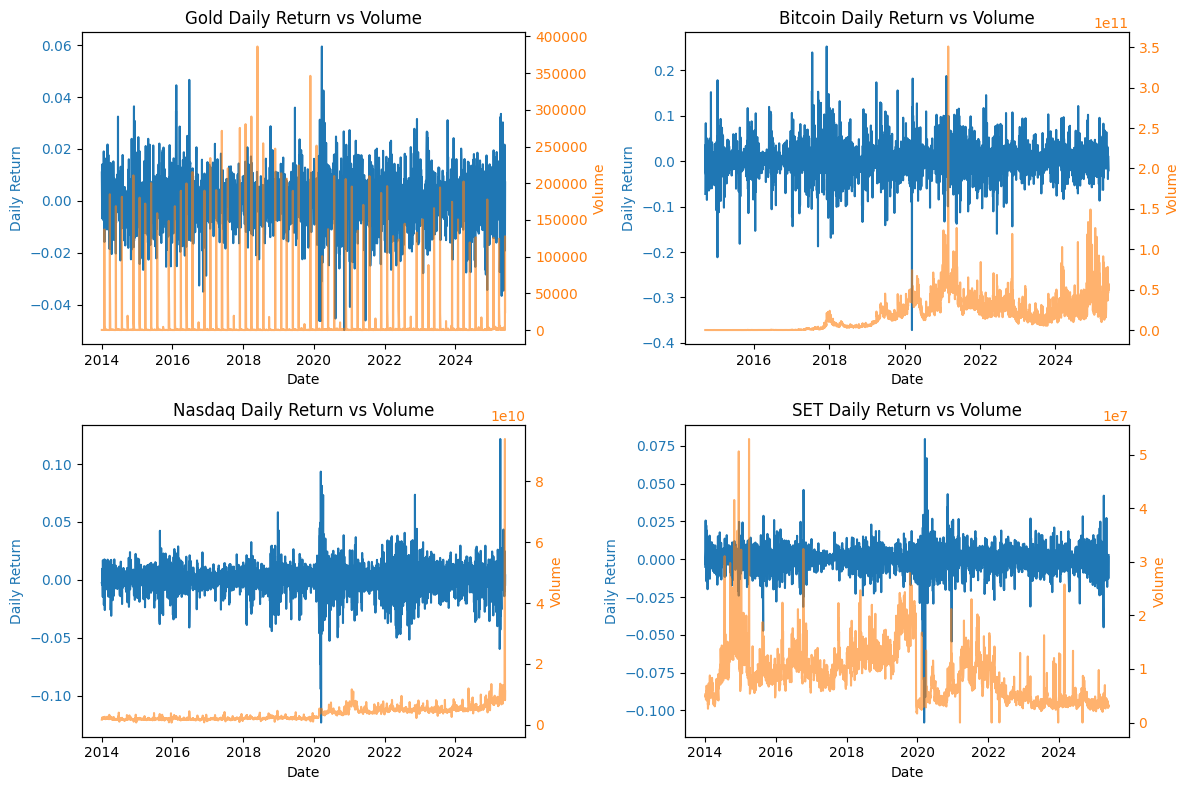

In [22]:
assets = {
    "Gold": (gold_df, "Gold_Volume"),
    "Bitcoin": (btc_df, "Bitcoin_Volume"),
    "Nasdaq": (nasdaq_df, "Nasdaq_Volume"),
    "SET": (set_df, "SET_Volume")
}

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for i, (name, (df, volume_col)) in enumerate(assets.items()):
    ax = axs[i]
    ax2 = ax.twinx()

    ax.plot(df.index, df["Return"], label="Return", color="tab:blue")
    ax.set_ylabel("Daily Return", color="tab:blue")
    ax.tick_params(axis='y', labelcolor='tab:blue')

    ax2.plot(df.index, df[volume_col], label="Volume", color="tab:orange", alpha=0.6)
    ax2.set_ylabel("Volume", color="tab:orange")
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    ax.set_title(f"{name} Daily Return vs Volume")
    ax.set_xlabel("Date")

fig.tight_layout()
plt.show()

### 2.2 Correlation of Close Price
- Only SET that has negative correlation to other assets.
- Gold and Bitcoin are generally not correlated, or sometimes negatively correlated.
- Maybe because the selected time period (COVID19 may cause all assets to surge at the same time).

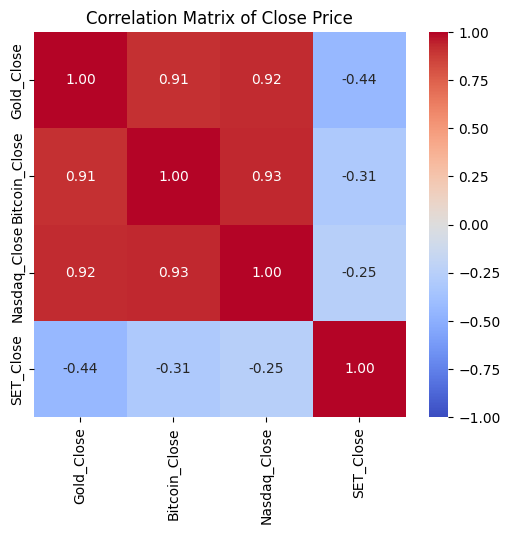

In [81]:
assets_name = ["Gold", "Bitcoin", "Nasdaq", "SET"]

cl_price_df = merged_df[[f"{asset}_Close" for asset in assets_name]].dropna()
correlation_matrix = cl_price_df.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1
)
plt.title("Correlation Matrix of Close Price")
plt.show()

## 3. LSTM modeling

### 3.1 Code which format a dataset and LSTM model for forecasting

In [38]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=100, num_layers=3):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

### 3.2 Train a separate LSTM model for each asset to forecast the next day's price
- SEQ_LEN: Use 30 days of historical price data to help the model learn and forecast the next day's price.
- EPOCHS: Let the model be trained on all data 30 times to adjust the parameter values ​​for better accuracy.
- BATCH_SIZE: The data is divided into sets of 32 samples and trained gradually to make calculations faster and more stable.
- Using train 80% of data, test 20% of data.

In [88]:
SEQ_LEN = 30
EPOCHS = 30
BATCH_SIZE = 32
assets = ["Gold", "Bitcoin", "Nasdaq", "SET"]

results = {}
trained_models = {}


for asset in assets:
    print(f"\n Training LSTM for: {asset}")
    col = f"{asset}_Close"
    df = merged_df[[col]].dropna()

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df)

    def create_seq(data, seq_len):
        X, y = [], []
        for i in range(len(data) - seq_len):
            X.append(data[i:i+seq_len])
            y.append(data[i+seq_len])
        return np.array(X), np.array(y)
    
    X, y = create_seq(scaled, SEQ_LEN)
    X = X.reshape(-1, SEQ_LEN, 1)
    y = y.reshape(-1, 1)

    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(TimeSeriesDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

    model = LSTMModel()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(EPOCHS):
        model.train()
        for xb, yb in train_loader:
            out = model(xb)
            loss = criterion(out, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1}/{EPOCHS} Loss: {loss.item():.6f}")

    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            out = model(xb)
            preds.append(out.numpy())
            actuals.append(yb.numpy())
    preds = np.vstack(preds)
    actuals = np.vstack(actuals)

    predicted_price = scaler.inverse_transform(preds)
    actual_price = scaler.inverse_transform(actuals)
    
    trained_models[asset] = model
    results[asset] = (actual_price, predicted_price)


 Training LSTM for: Gold
Epoch 1/30 Loss: 0.000826
Epoch 2/30 Loss: 0.000260
Epoch 3/30 Loss: 0.000237
Epoch 4/30 Loss: 0.000407
Epoch 5/30 Loss: 0.000215
Epoch 6/30 Loss: 0.000326
Epoch 7/30 Loss: 0.000094
Epoch 8/30 Loss: 0.000139
Epoch 9/30 Loss: 0.000152
Epoch 10/30 Loss: 0.000266
Epoch 11/30 Loss: 0.000164
Epoch 12/30 Loss: 0.000066
Epoch 13/30 Loss: 0.000204
Epoch 14/30 Loss: 0.000069
Epoch 15/30 Loss: 0.000126
Epoch 16/30 Loss: 0.000119
Epoch 17/30 Loss: 0.000103
Epoch 18/30 Loss: 0.000088
Epoch 19/30 Loss: 0.000047
Epoch 20/30 Loss: 0.000074
Epoch 21/30 Loss: 0.000266
Epoch 22/30 Loss: 0.000041
Epoch 23/30 Loss: 0.000097
Epoch 24/30 Loss: 0.000053
Epoch 25/30 Loss: 0.000046
Epoch 26/30 Loss: 0.000068
Epoch 27/30 Loss: 0.000039
Epoch 28/30 Loss: 0.000137
Epoch 29/30 Loss: 0.000070
Epoch 30/30 Loss: 0.000024

 Training LSTM for: Bitcoin
Epoch 1/30 Loss: 0.000568
Epoch 2/30 Loss: 0.000204
Epoch 3/30 Loss: 0.000364
Epoch 4/30 Loss: 0.000044
Epoch 5/30 Loss: 0.000222
Epoch 6/30 Los

## 4. Result

### 4.1 Compare actual & predicted
- Based on RMSE, our LSTM model is good to predict SET.
- Gold & Nasdaq is quite normal.
- Bitcoin is bad due to high volatilities, maybe need more feature to help model predict more precisely.

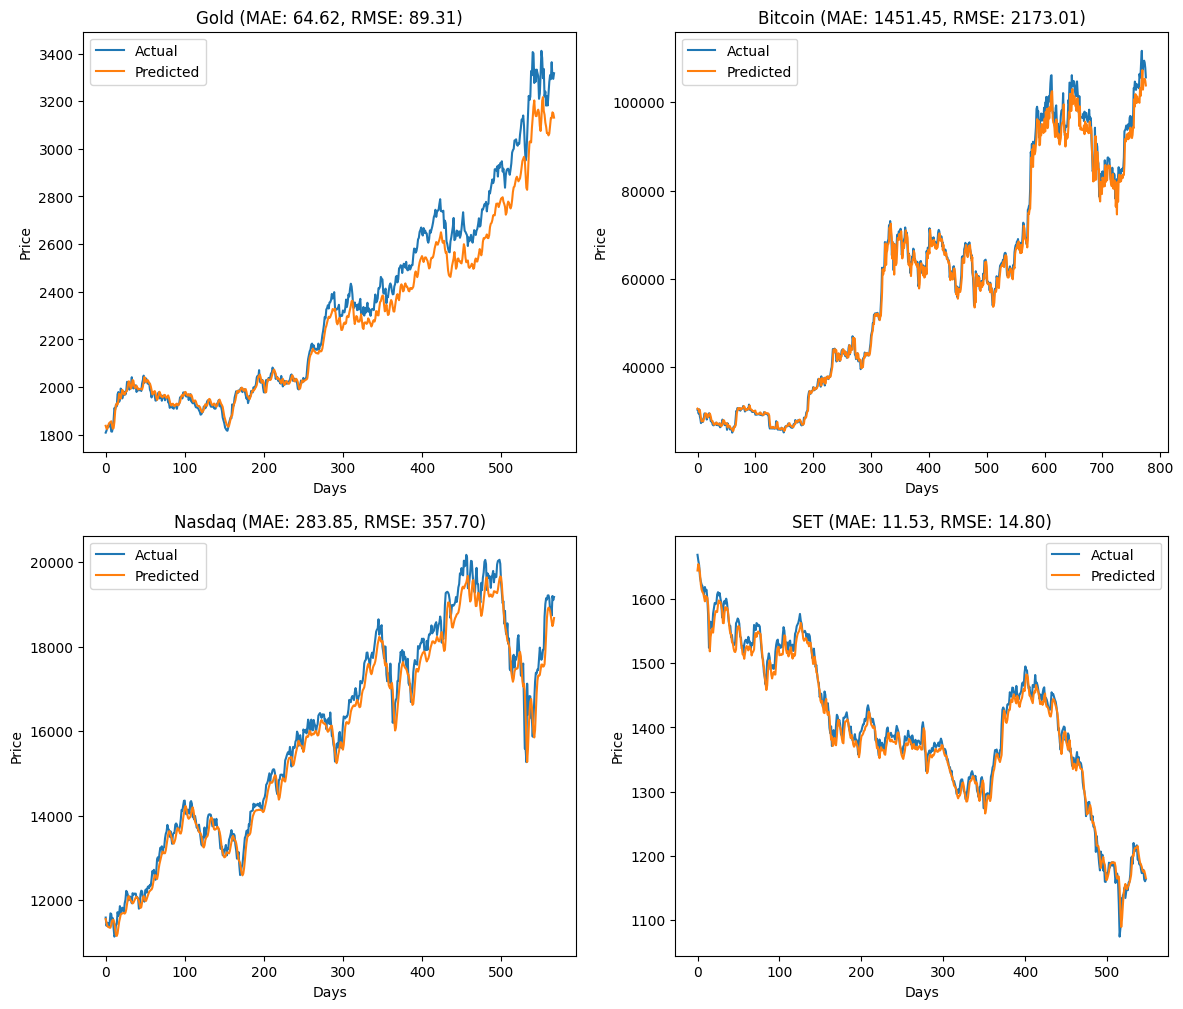

In [89]:
fig, axs = plt.subplots(2, 2, figsize=(14, 12))
axs = axs.flatten()

for i, asset in enumerate(assets):
    actual, predicted = results[asset]

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    ax = axs[i]
    ax.plot(actual, label="Actual")
    ax.plot(predicted, label="Predicted")

    ax.set_title(f"{asset} (MAE: {mae:.2f}, RMSE: {rmse:.2f})")
    ax.set_xlabel("Days")
    ax.set_ylabel("Price")
    ax.legend()

### 4.2 Actual & Predicted data on last 3 days 

In [90]:
summary_tables = {}

for asset, (actual_array, predicted_array) in results.items():
    actual = actual_array.flatten()
    predicted = predicted_array.flatten()

    df = pd.DataFrame({
        "Actual": actual,
        "Predicted": predicted,
        "Error": actual - predicted
    })

    summary_tables[asset] = df

In [91]:
combined_df = pd.concat(summary_tables, names=["Asset", "Index"])

for asset in summary_tables:
    print(f"\n {asset} - Last 3 Predictions")
    print(summary_tables[asset].tail(3))


 Gold - Last 3 Predictions
          Actual    Predicted       Error
565  3299.100098  3153.186523  145.913574
566  3293.600098  3148.522949  145.077148
567  3317.100098  3131.028809  186.071289

 Bitcoin - Last 3 Predictions
            Actual      Predicted        Error
773  108994.640625  105319.359375  3675.281250
774  107802.328125  104877.539062  2924.789062
775  105641.757812  103820.195312  1821.562500

 Nasdaq - Last 3 Predictions
           Actual     Predicted       Error
565  19199.162109  18487.068359  712.093750
566  19100.939453  18551.765625  549.173828
567  19175.869141  18677.751953  498.117188

 SET - Last 3 Predictions
          Actual    Predicted      Error
545  1163.420044  1177.216064 -13.796021
546  1160.739990  1172.084106 -11.344116
547  1164.010010  1165.604004  -1.593994


### 4.3 Forcast next 3 days
- Why do we forecast only the next 3 days?
    - Because the further out we forecast, the faster the accuracy drops, especially with high-volatility assets like Bitcoin.
    - Our model is also primarily designed for short-term forecasting.

In [92]:
forecast_3d = defaultdict(list)

for asset in assets:
    col = f"{asset}_Close"
    df = merged_df[[col]].dropna()
    
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df)

    last_seq = scaled[-SEQ_LEN:].reshape(1, SEQ_LEN, 1)

    model = trained_models[asset]
    model.eval()

    preds_scaled = []

    for _ in range(3):
        with torch.no_grad():
            x = torch.tensor(last_seq, dtype=torch.float32)
            pred = model(x).numpy().flatten()[0]
            preds_scaled.append(pred)

        last_seq = np.append(last_seq[:, 1:, :], [[[pred]]], axis=1)

    preds_real = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()
    forecast_3d[asset] = preds_real

for asset in forecast_3d:
    print(f"\n {asset} - 3-Day Forecast:")
    df_forecast = pd.DataFrame(forecast_3d[asset], columns=["Predicted Price"])
    df_forecast.index = [f"t+{i+1}" for i in range(3)]
    print(df_forecast)


 Gold - 3-Day Forecast:
     Predicted Price
t+1      3138.655029
t+2      3066.184326
t+3      2967.464355

 Bitcoin - 3-Day Forecast:
     Predicted Price
t+1    101831.710938
t+2     98238.406250
t+3     95145.914062

 Nasdaq - 3-Day Forecast:
     Predicted Price
t+1     18794.144531
t+2     18746.267578
t+3     18597.453125

 SET - 3-Day Forecast:
     Predicted Price
t+1      1163.773682
t+2      1164.588867
t+3      1166.259644


## 5. Conclusion
1. We using LSTM model to forecast Gold, Bitcoin, Nasdaq, SET.
2. Based on RMSE, our model is best perform on SET and bad perform on Bitcoin.
3. Our model can be more tune by adding more feature, technique or etc.
4. In the next 3 days (1-3 June, 2025), our model predict that SET will increase, while other are decrease.